In [1]:
# # Data Augmentation: A Data-Centric Solution for Small Data
# 
# ## Using the MNIST Dataset
# 
# This notebook demonstrates **Data Augmentation** as a solution to the small data problem:
# 
# - **What is Data Augmentation?** Applying label-preserving transformations to existing data to create new, realistic variations.
# - **Why does it help?** It increases the effective size of the training set, helping the model learn invariance to irrelevant changes.
# - **How do we measure its effectiveness?** We train models with different amounts of augmented data and compare test accuracy.
# 
# **Key Question:** How much does data augmentation improve performance when we have very few labeled samples?

# %% [markdown]
# ## 1. Setup and Imports

# %%
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import rotate, shift, zoom
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# ## 2. Load and Prepare MNIST Dataset

# Load MNIST (using a subset for speed)
print("Loading MNIST dataset...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='pandas')

# Convert to appropriate types
X = X.astype(np.float32)
y = y.astype(np.int32)

# Normalize pixel values to [0, 1]
X = X / 255.0

print(f"Dataset shape: X: {X.shape}, y: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

# ## 3. Split Data: Train, Validation, and Test

# Split into train (60%), validation (10%), and test (30%)
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.75, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train_full.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Loading MNIST dataset...
Dataset shape: X: (70000, 784), y: (70000,)
Number of classes: 10
Training set: 42000 samples
Validation set: 7000 samples
Test set: 21000 samples


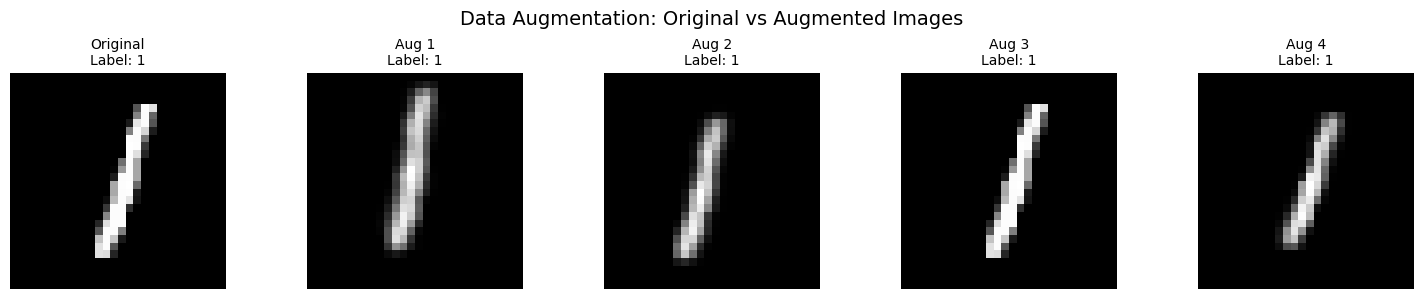

In [5]:
# ## 4. Define Augmentation Functions
# 
# We implement a **random combination** of transformations:
# - **Rotation**: Rotate the image by a random angle (±15°).
# - **Shift**: Translate the image horizontally and vertically (±2px).
# - **Zoom**: Zoom in or out (0.8x to 1.2x).
# 
# Each image receives a random subset of these transformations.

def resize_to_28(image):
    """Resize any 2D image to 28x28 by padding or cropping."""
    h, w = image.shape
    if h == 28 and w == 28:
        return image
    
    if h > 28:
        start_h = (h - 28) // 2
        image = image[start_h:start_h+28, :]
        h = 28
    if w > 28:
        start_w = (w - 28) // 2
        image = image[:, start_w:start_w+28]
        w = 28
    
    if h < 28:
        pad_top = (28 - h) // 2
        pad_bottom = 28 - h - pad_top
        image = np.pad(image, ((pad_top, pad_bottom), (0, 0)), mode='constant', constant_values=0)
        h = 28
    if w < 28:
        pad_left = (28 - w) // 2
        pad_right = 28 - w - pad_left
        image = np.pad(image, ((0, 0), (pad_left, pad_right)), mode='constant', constant_values=0)
        w = 28
    
    return image

def rotate_image(image, angle_range=(-15, 15)):
    """Rotate image by a random angle within the specified range."""
    angle = np.random.uniform(angle_range[0], angle_range[1])
    return rotate(image, angle, reshape=False, order=1, mode='constant', cval=0)

def shift_image(image, shift_range=(-2, 2)):
    """Shift image horizontally and vertically by random amounts."""
    shift_x = np.random.uniform(shift_range[0], shift_range[1])
    shift_y = np.random.uniform(shift_range[0], shift_range[1])
    return shift(image, (shift_y, shift_x), order=1, mode='constant', cval=0)

def zoom_image(image, zoom_range=(0.8, 1.2)):
    """Zoom image by a random factor and resize back to 28x28."""
    zoom_factor = np.random.uniform(zoom_range[0], zoom_range[1])
    zoomed = zoom(image, zoom_factor, order=1, mode='constant', cval=0)
    return resize_to_28(zoomed)

def augment_image(image):
    """
    Apply a random combination of augmentations to an image.
    Each transformation is applied with 50% probability.
    """
    image_2d = image.reshape(28, 28)
    augmented = image_2d.copy()
    
    # Randomly apply transformations
    if np.random.random() > 0.5:
        augmented = rotate_image(augmented)
    if np.random.random() > 0.5:
        augmented = shift_image(augmented)
    if np.random.random() > 0.5:
        augmented = zoom_image(augmented)
    
    return augmented.flatten()

def augment_dataset(X, y, augmentation_factor=5):
    """
    Create augmented dataset by applying transformations to each sample.
    
    Parameters:
    - X: Original features
    - y: Original labels
    - augmentation_factor: How many augmented versions per original sample
    
    Returns:
    - X_aug: Augmented features
    - y_aug: Augmented labels (same as original)
    """
    X_aug = []
    y_aug = []
    
    for i in range(len(X)):
        # Keep the original image
        X_aug.append(X[i])
        y_aug.append(y[i])
        
        # Create augmented versions
        for _ in range(augmentation_factor):
            augmented = augment_image(X[i])
            X_aug.append(augmented)
            y_aug.append(y[i])
    
    return np.array(X_aug), np.array(y_aug)

# ## 5. Visualize Augmented Images
# 
# Let's see what the augmented images look like.

# Select a random image from the training set
sample_idx = np.random.randint(0, len(X_train_full))
original_image = X_train_full[sample_idx].reshape(28, 28)
label = y_train_full[sample_idx]

# Generate augmented versions
augmented_images = []
titles = ['Original', 'Aug 1', 'Aug 2', 'Aug 3', 'Aug 4']

for i in range(4):
    aug_flat = augment_image(X_train_full[sample_idx])
    aug_image = aug_flat.reshape(28, 28)
    augmented_images.append(aug_image)

# Plot the original and augmented images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Original
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title(f'Original\nLabel: {label}', fontsize=10)
axes[0].axis('off')

# Augmented versions
for i, (ax, img) in enumerate(zip(axes[1:], augmented_images)):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Aug {i+1}\nLabel: {label}', fontsize=10)
    ax.axis('off')

plt.suptitle('Data Augmentation: Original vs Augmented Images', fontsize=14)
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ## 6. Helper Functions for Experiment

def get_base_dataset(X_train, y_train, n_samples_per_class=10, random_seed=42):
    """
    Get a balanced subset of the training data.
    
    Parameters:
    - X_train: Full training features
    - y_train: Full training labels
    - n_samples_per_class: Number of samples per class
    - random_seed: Random seed for reproducibility
    
    Returns:
    - X_base: Subset features
    - y_base: Subset labels
    """
    np.random.seed(random_seed)
    indices = []
    for class_label in range(10):
        class_indices = np.where(y_train == class_label)[0]
        n_to_sample = min(n_samples_per_class, len(class_indices))
        selected = np.random.choice(class_indices, size=n_to_sample, replace=False)
        indices.extend(selected)
    
    X_base = X_train[indices]
    y_base = y_train[indices]
    
    return X_base, y_base

def train_and_evaluate(X_train, y_train, X_test, y_test):
    """
    Train a logistic regression model and evaluate on test set.
    
    Parameters:
    - X_train: Training features
    - y_train: Training labels
    - X_test: Test features
    - y_test: Test labels
    
    Returns:
    - test_acc: Test accuracy
    - train_acc: Training accuracy
    """
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    
    return train_acc, test_acc

# ## 7. Main Experiment
# 
# We test different **initial labeled data sizes** and **augmentation factors**.
# 
# **Experiment Setup:**
# - **Initial labeled data**: 5, 10, 20, 50 samples per class (total: 50, 100, 200, 500).
# - **Augmentation factors**: 0x (baseline), 2x, 3x, 5x, 10x, 20x, 50x.
# - **Number of runs**: 3 runs for averaging.

# ============================================================
# EXPERIMENT PARAMETERS - EASILY ADJUSTABLE
# ============================================================

# List of samples per class to test
SAMPLES_PER_CLASS_LIST = [5, 10, 20, 50]  # -> total samples: 50, 100, 200, 500

# List of augmentation factors to test
AUGMENTATION_FACTORS = [0, 2, 3, 5, 10, 20, 50]  # 0 = no augmentation (baseline)

# Number of runs for averaging
N_RUNS = 3

print("=" * 60)
print("DATA AUGMENTATION EXPERIMENT")
print("=" * 60)
print(f"Samples per class to test: {SAMPLES_PER_CLASS_LIST}")
print(f"Total samples: {[s*10 for s in SAMPLES_PER_CLASS_LIST]}")
print(f"Augmentation factors: {AUGMENTATION_FACTORS}")
print(f"Number of runs per configuration: {N_RUNS}")
print("=" * 60)

# ## 8. Run the Experiment

# List to store all results
all_results = []

# Loop over different initial labeled data sizes
for n_samples_per_class in SAMPLES_PER_CLASS_LIST:
    print(f"\n{'='*60}")
    print(f"Testing: {n_samples_per_class} samples per class (total: {n_samples_per_class*10})")
    print(f"{'='*60}")
    
    # Loop over augmentation factors
    for factor in AUGMENTATION_FACTORS:
        print(f"  Augmentation factor: {factor}x")
        
        # Store results for this configuration
        run_results = []
        
        for run in range(N_RUNS):
            # Get base dataset (fixed number of labeled samples per class)
            X_base, y_base = get_base_dataset(
                X_train_full, y_train_full, 
                n_samples_per_class=n_samples_per_class, 
                random_seed=42 + run * 100
            )
            
            # Apply augmentation if factor > 0
            if factor == 0:
                X_train_aug = X_base
                y_train_aug = y_base
                total_samples = len(X_base)
            else:
                X_train_aug, y_train_aug = augment_dataset(
                    X_base, y_base, 
                    augmentation_factor=factor
                )
                total_samples = len(X_train_aug)
            
            # Train and evaluate
            train_acc, test_acc = train_and_evaluate(
                X_train_aug, y_train_aug, X_test, y_test
            )
            
            # Store results
            run_results.append({
                'run': run,
                'n_samples_per_class': n_samples_per_class,
                'n_base_samples': len(X_base),
                'augmentation_factor': factor,
                'total_samples': total_samples,
                'train_acc': train_acc,
                'test_acc': test_acc
            })
            
            print(f"    Run {run+1}: Train={train_acc:.4f}, Test={test_acc:.4f}")
        
        # Compute mean and std for this configuration
        train_accs = [r['train_acc'] for r in run_results]
        test_accs = [r['test_acc'] for r in run_results]
        
        print(f"    Summary: Test Acc = {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}")
        
        # Add aggregated results
        all_results.append({
            'n_samples_per_class': n_samples_per_class,
            'n_base_samples': len(X_base),
            'augmentation_factor': factor,
            'total_samples': total_samples,
            'train_acc_mean': np.mean(train_accs),
            'train_acc_std': np.std(train_accs),
            'test_acc_mean': np.mean(test_accs),
            'test_acc_std': np.std(test_accs),
            'n_runs': N_RUNS
        })

print("\n" + "=" * 60)
print("Experiment completed!")
print("=" * 60)

# ## 9. Convert Results to DataFrame
df_results = pd.DataFrame(all_results)

print("Results Summary:")
print(df_results.to_string())

DATA AUGMENTATION EXPERIMENT
Samples per class to test: [5, 10, 20, 50]
Total samples: [50, 100, 200, 500]
Augmentation factors: [0, 2, 3, 5, 10, 20, 50]
Number of runs per configuration: 3

Testing: 5 samples per class (total: 50)
  Augmentation factor: 0x
    Run 1: Train=1.0000, Test=0.6670
    Run 2: Train=1.0000, Test=0.5813
    Run 3: Train=1.0000, Test=0.6451
    Summary: Test Acc = 0.6311 ± 0.0363
  Augmentation factor: 2x
    Run 1: Train=1.0000, Test=0.6616
    Run 2: Train=1.0000, Test=0.5965
    Run 3: Train=1.0000, Test=0.6502
    Summary: Test Acc = 0.6361 ± 0.0284
  Augmentation factor: 3x
    Run 1: Train=1.0000, Test=0.7039
    Run 2: Train=1.0000, Test=0.6080
    Run 3: Train=1.0000, Test=0.6592
    Summary: Test Acc = 0.6571 ± 0.0392
  Augmentation factor: 5x
    Run 1: Train=1.0000, Test=0.6940
    Run 2: Train=1.0000, Test=0.6060
    Run 3: Train=1.0000, Test=0.6559
    Summary: Test Acc = 0.6520 ± 0.0360
  Augmentation factor: 10x
    Run 1: Train=1.0000, Test=0.6

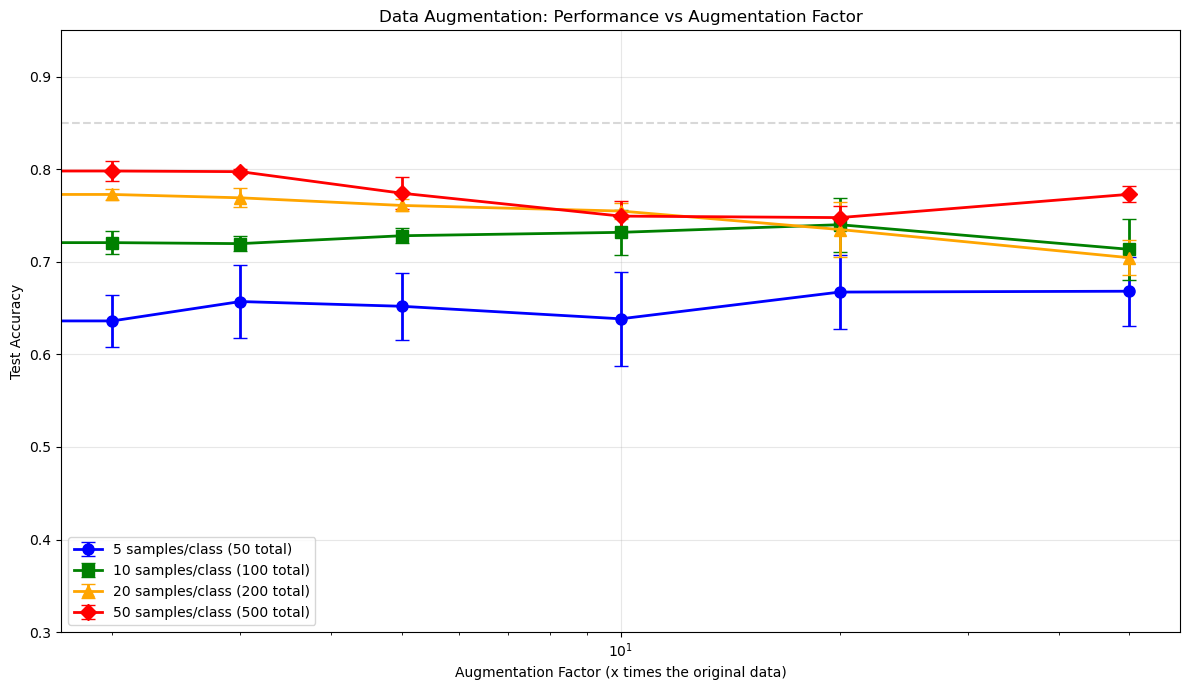

In [9]:
# ## 10. Visualization: Performance vs Augmentation Factor
# 
# We plot the test accuracy vs augmentation factor for each initial data size.

# Create the main plot
fig, ax = plt.subplots(figsize=(12, 7))

# Color map for different initial data sizes
colors = ['blue', 'green', 'orange', 'red']
markers = ['o', 's', '^', 'D']

for i, n_samples in enumerate(SAMPLES_PER_CLASS_LIST):
    df_subset = df_results[df_results['n_samples_per_class'] == n_samples]
    
    # Sort by augmentation factor
    df_subset = df_subset.sort_values('augmentation_factor')
    
    # Plot with error bars
    ax.errorbar(
        df_subset['augmentation_factor'],
        df_subset['test_acc_mean'],
        yerr=df_subset['test_acc_std'],
        fmt=f'{markers[i]}-',
        color=colors[i],
        capsize=5,
        linewidth=2,
        markersize=8,
        label=f'{n_samples} samples/class ({n_samples*10} total)'
    )

ax.set_xlabel('Augmentation Factor (x times the original data)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Data Augmentation: Performance vs Augmentation Factor')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_ylim(0.3, 0.95)

# Add horizontal line at 0.85 (reference)
ax.axhline(y=0.85, color='gray', linestyle='--', alpha=0.3, label='Reference: ~85% with full data')

plt.tight_layout()
plt.savefig('augmentation_performance.png', dpi=150, bbox_inches='tight')
plt.show()